# Ambivision badgerpidgeon demo

In [ ]:
!pip3 install -q kagglehub torch torchvision transformers pillow

zsh:1: command not found: pip


In [2]:
import re
from pathlib import Path
import torch
import torch.nn.functional as F
from PIL import Image
import kagglehub
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights
from transformers import CLIPModel, CLIPProcessor

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.0.1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("anonymac12i3/ambivision")
root = Path(path)
sub = root / "Neurips_collection" / "No_Direction"
if not sub.is_dir():
    for p in root.rglob("No_Direction"):
        if p.is_dir():
            sub = p
            break
img_path = sub / "badgerturtle.png"
txt_path = sub / "badgerturtle.txt"
if not img_path.is_file():
    cands = list(sub.glob("badgerturtle.*"))
    cands = [p for p in cands if p.suffix.lower() in {".jpg", ".png"}]
    if not cands:
        raise RuntimeError("badgerturtle image not found")
    img_path = cands[0]
if not txt_path.is_file():
    raise RuntimeError("badgerturtle.txt not found")
print("image:", img_path)
print("txt:", txt_path)

image: /Users/anikapandey/.cache/kagglehub/datasets/anonymac12i3/ambivision/versions/10/Ambivision/Neurips_collection/No_Direction/badgerturtle.png
txt: /Users/anikapandey/.cache/kagglehub/datasets/anonymac12i3/ambivision/versions/10/Ambivision/Neurips_collection/No_Direction/badgerturtle.txt


In [4]:
def parse_box_animals(txt_path):
    a1 = a2 = None
    for line in open(txt_path, encoding="utf-8", errors="replace"):
        line = line.strip()
        m1 = re.match(r"boundingbox1\s+(.+)", line, re.I)
        m2 = re.match(r"boundingbox2\s+(.+)", line, re.I)
        if m1:
            a1 = m1.group(1).strip()
        if m2:
            a2 = m2.group(1).strip()
    return a1, a2

def norm_animal(s):
    s = (s or "").lower().strip()
    if s == "turtle":
        s = "turtle"
    return s

def pred_matches_animal(pred_label, animal):
    a = norm_animal(animal)
    p = pred_label.lower()
    if a in p:
        return True
    for part in p.split(","):
        part = part.strip()
        if a in part or part in a:
            return True
    return False

def best_rank_for_pair(pred_list, a1, a2):
    for i, p in enumerate(pred_list, start=1):
        if pred_matches_animal(p, a1) or pred_matches_animal(p, a2):
            return i
    return None

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
res_w = ResNet50_Weights.DEFAULT
resnet = resnet50(weights=res_w).to(device).eval()
res_pre = res_w.transforms()
classes = list(res_w.meta["categories"])
eff_w = EfficientNet_B0_Weights.DEFAULT
effnet = efficientnet_b0(weights=eff_w).to(device).eval()
eff_pre = eff_w.transforms()
vit_w = ViT_B_16_Weights.DEFAULT
vit = vit_b_16(weights=vit_w).to(device).eval()
vit_pre = vit_w.transforms()
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [6]:
clip_texts = [f"a photo of a {c}" for c in classes]
with torch.no_grad():
    text_emb_parts = []
    for i in range(0, len(clip_texts), 256):
        inp = clip_processor(text=clip_texts[i:i+256], return_tensors="pt", padding=True, truncation=True).to(device)
        te = F.normalize(clip_model.get_text_features(**inp), dim=-1)
        text_emb_parts.append(te.cpu())
    clip_text_emb = torch.cat(text_emb_parts, dim=0).to(device)

@torch.no_grad()
def torch_topk(model, preprocess, pil_img, k=5):
    x = preprocess(pil_img).unsqueeze(0).to(device)
    idx = model(x).squeeze(0).topk(k).indices.tolist()
    return [classes[j] for j in idx]

@torch.no_grad()
def clip_topk(pil_img, k=5):
    inp = clip_processor(images=pil_img, return_tensors="pt").to(device)
    imf = F.normalize(clip_model.get_image_features(**inp), dim=-1)
    sim = (imf @ clip_text_emb.T).squeeze(0)
    idx = sim.topk(k).indices.tolist()
    return [classes[j] for j in idx]

@torch.no_grad()
def torch_two_choice(model, preprocess, pil_img, a1, a2):
    x = preprocess(pil_img).unsqueeze(0).to(device)
    probs = model(x).softmax(dim=1).squeeze(0)
    s1 = 0.0
    s2 = 0.0
    for i, c in enumerate(classes):
        if pred_matches_animal(c, a1):
            s1 += float(probs[i])
        if pred_matches_animal(c, a2):
            s2 += float(probs[i])
    if s1 == 0.0 and s2 == 0.0:
        return "unknown", s1, s2
    return ("box1" if s1 >= s2 else "box2"), s1, s2

@torch.no_grad()
def clip_two_choice(pil_img, a1, a2):
    prompts = [f"a photo of a {a1}", f"a photo of a {a2}"]
    inp = clip_processor(text=prompts, images=pil_img, return_tensors="pt", padding=True).to(device)
    logits = clip_model(**inp).logits_per_image.squeeze(0)
    probs = logits.softmax(dim=0)
    return ("box1" if probs[0] >= probs[1] else "box2"), float(probs[0]), float(probs[1])

categories: box1=badger box2=turtle

no-choice top5
ResNet50 top1= mask top5_hit= True rank= 5
EfficientNet-B0 top1= mask top5_hit= False rank= None
ViT-B/16 top1= mask top5_hit= True rank= 5
CLIP top1= badger top5_hit= True rank= 1

two-choice (box1 vs box2)
ResNet50 box1 0.015979 0.001604
EfficientNet-B0 box2 0.000233 0.000613
ViT-B/16 box1 0.015474 0.001728
CLIP box1 0.984744 0.015255


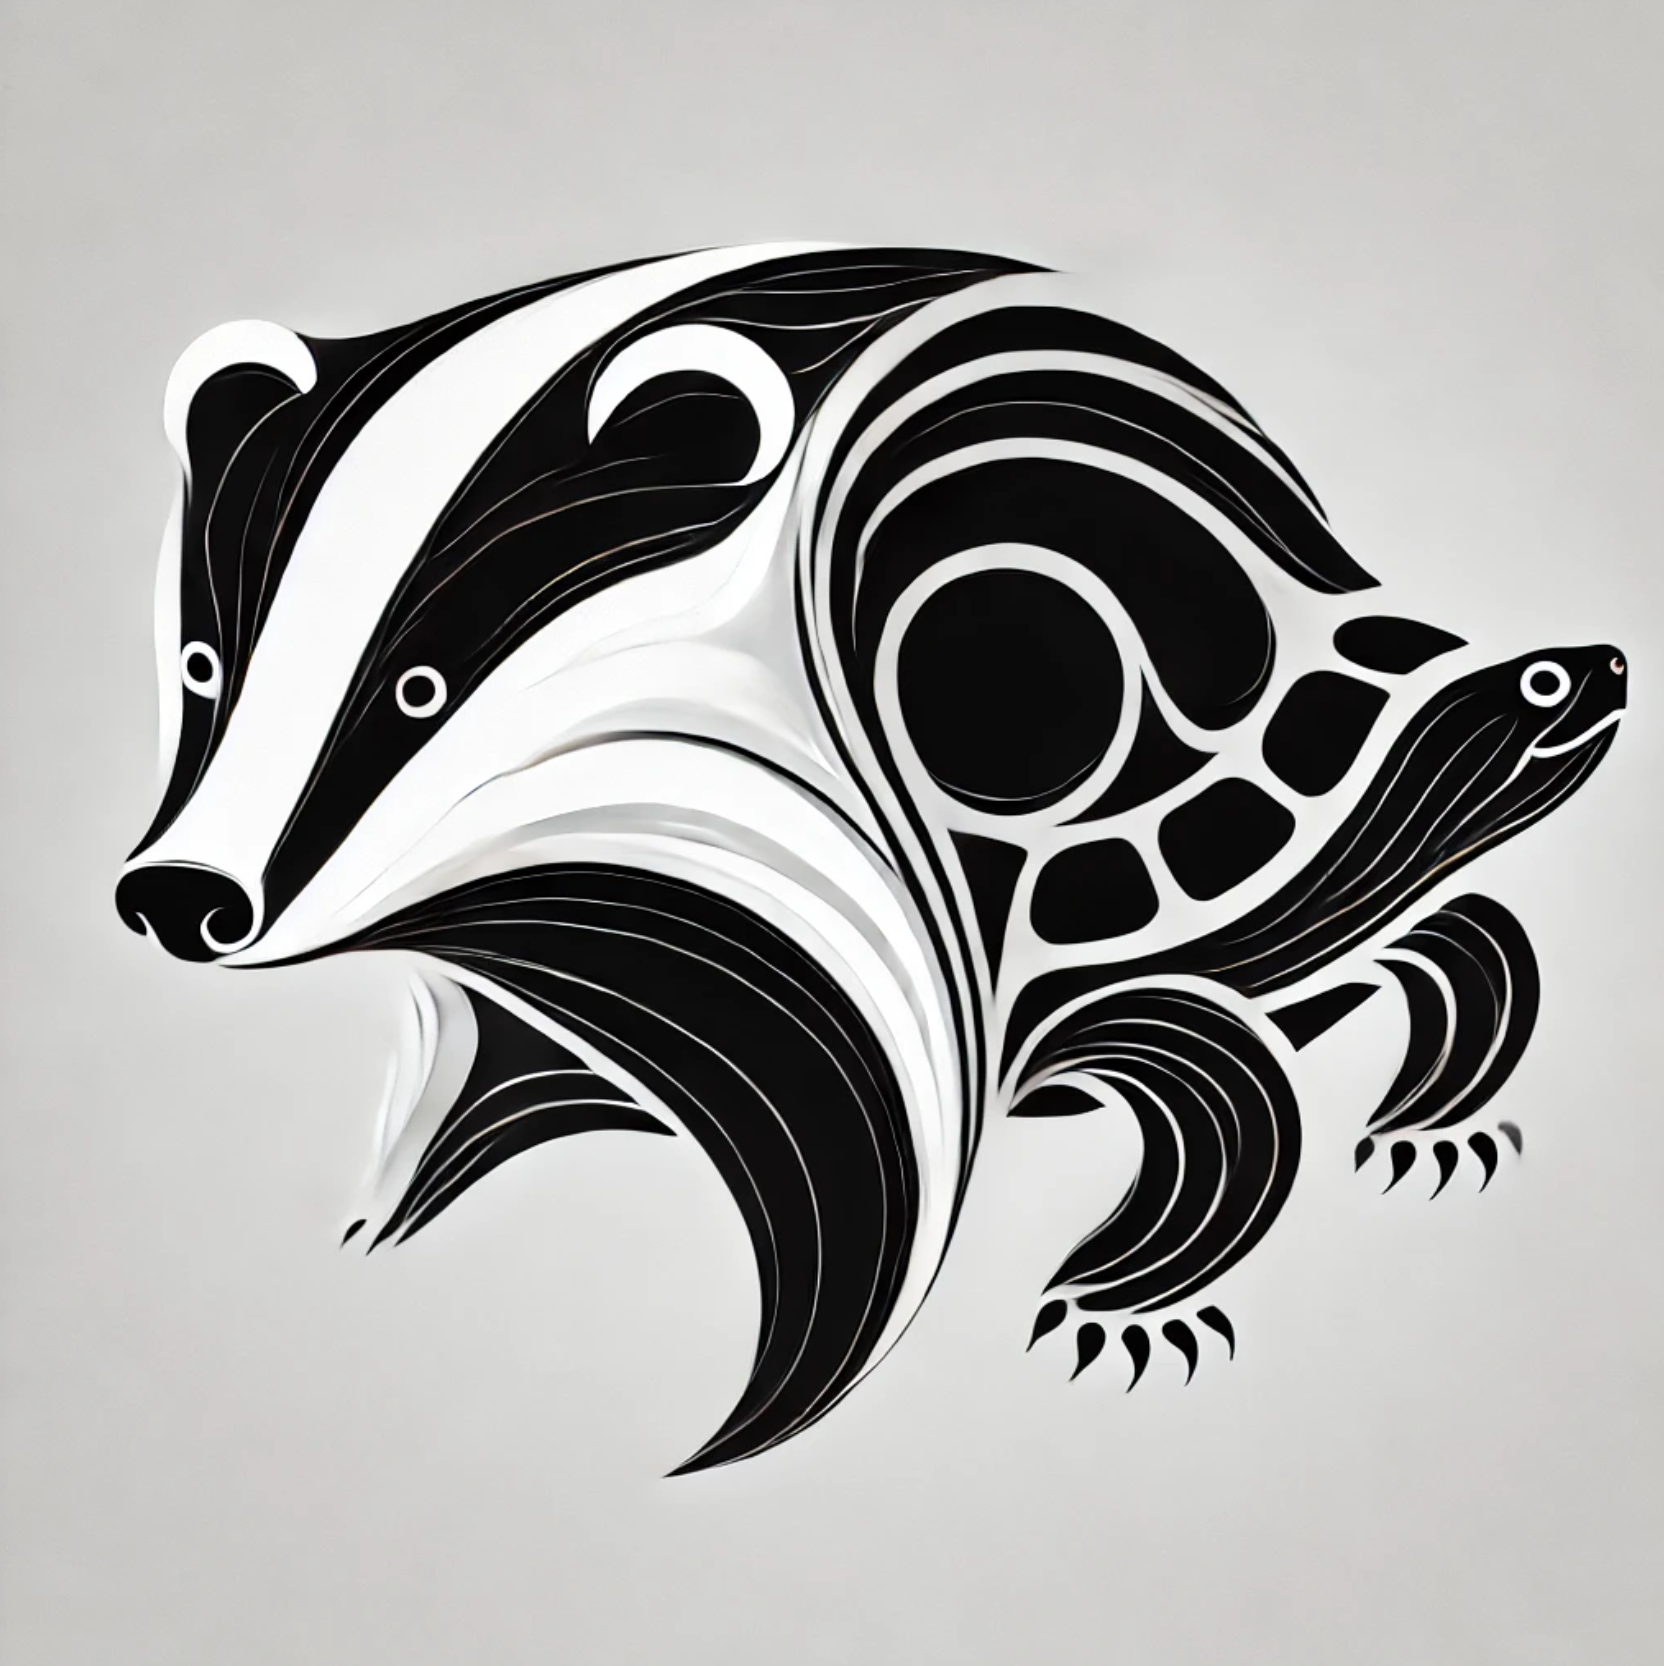

In [ ]:
a1, a2 = parse_box_animals(txt_path)
img = Image.open(img_path).convert("RGB")
print("categories:", "box1=" + str(a1), "box2=" + str(a2))
print()
r5 = torch_topk(resnet, res_pre, img, k=5)
e5 = torch_topk(effnet, eff_pre, img, k=5)
v5 = torch_topk(vit, vit_pre, img, k=5)
c5 = clip_topk(img, k=5)
print("no-choice top5")
for name, top5 in [("ResNet50", r5), ("EfficientNet-B0", e5), ("ViT-B/16", v5), ("CLIP", c5)]:
    rank = best_rank_for_pair(top5, a1, a2)
    print(name, "top1=", top5[0], "top5_hit=", rank is not None, "rank=", rank)
print()
print("two-choice (box1 vs box2)")
pr, sr1, sr2 = torch_two_choice(resnet, res_pre, img, a1, a2)
pe, se1, se2 = torch_two_choice(effnet, eff_pre, img, a1, a2)
pv, sv1, sv2 = torch_two_choice(vit, vit_pre, img, a1, a2)
pc, sc1, sc2 = clip_two_choice(img, a1, a2)
print("ResNet50", pr, round(sr1, 6), round(sr2, 6))
print("EfficientNet-B0", pe, round(se1, 6), round(se2, 6))
print("ViT-B/16", pv, round(sv1, 6), round(sv2, 6))
print("CLIP", pc, round(sc1, 6), round(sc2, 6))
img